# Spatial Dataset Pre-Processing (Multiple Slices, Individually by Timepoint)
Script that converts a pre-processed AnnData object from STARmap/SPARTseq to a Vitessce-compatible Zarr file format. 

**Input:** AnnData Object for Spatial Data 

**Output:** Zarr File 

### Load Packages

In [2]:
import anndata as ad 
import scanpy as sc
import numpy as np
import pandas as pd 
import matplotlib as mpl
from matplotlib import rcParams
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
import os

from vitessce import (
    VitessceConfig,
    Component as cm,
    CoordinationType as ct,
    AnnDataWrapper,
)
from vitessce.data_utils import (
    optimize_adata,
    VAR_CHUNK_SIZE,
)

warnings.simplefilter(action="ignore", category=Warning)

sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.verbosity = 3

print("All packages loaded successfully!")

All packages loaded successfully!


In [3]:
path = "/Users/iriskwon/Desktop/mouse-cereb-dev/"
os.chdir(path)
# verify the change
print("New working directory:", os.getcwd())

sc.logging.print_header()
sc.set_figure_params(facecolor="white", figsize=(15, 15))
sc.settings.verbosity = 3

New working directory: /Users/iriskwon/Desktop/mouse-cereb-dev
scanpy==1.10.3 anndata==0.10.9 umap==0.5.7 numpy==1.24.4 scipy==1.9.1 pandas==2.2.3 scikit-learn==1.6.1 statsmodels==0.14.4 pynndescent==0.5.13


### Define functions 

In [4]:
def scale_spatial(adata, scale_factor=10000):
    """
    Aspect-ratio-preserving scaling for spatial coordinates data. 
    """
    adata = adata.copy() 
    spatial = adata.obsm["spatial"]
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Get min and max to calculate range of spatial data 
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()

    # Determine aspect-ratio-preserving scaling
    x_range = x_max - x_min
    y_range = y_max - y_min
    max_range = max(x_range, y_range)

    # Scale both to [0, scale_factor] while preserving relative position
    x_scaled = (x - x_min) / max_range * scale_factor
    y_scaled = (y - y_min) / max_range * scale_factor

    adata.obsm["spatial"] = np.vstack([x_scaled, y_scaled]).T

    return adata 

In [5]:
def subset_top10_deg(adata, groupby="cell_types", n_top_genes=10, method="wilcoxon"):
    sc.tl.rank_genes_groups(adata, groupby=groupby, method=method, key_added="rank_genes_groups")

    top_genes = []
    groups = adata.obs[groupby].cat.categories
    for group in groups:
        top_genes_group = adata.uns["rank_genes_groups"]["names"][group][:n_top_genes]
        top_genes.extend(top_genes_group)

    top_genes = list(pd.unique(top_genes))
    top10_adata = adata[:, top_genes].copy()
    top10_adata.obs = adata.obs.copy()
    top10_adata.var = adata.var.loc[top_genes].copy()
    top10_adata.uns["top10_deg_genes"] = top_genes
    top10_adata.uns["rank_genes_groups"] = adata.uns["rank_genes_groups"]

    return top10_adata


### Define variables

In [6]:
spatial_target = {}

## E11 (Replace with the timepoint you want.)

In [7]:
orig_data = ad.read_h5ad(
    '/Users/iriskwon/Library/CloudStorage/OneDrive-SharedLibraries-JohnsHopkins/Manjari Anant - Iris/website_data_09_2025/data-for-vitessce/e13_data.h5ad'
)

In [8]:
orig_data

AnnData object with n_obs × n_vars = 32511 × 1742
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'broad_cell_types', 'cell_types', 'excitatory', 'inhibitory'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial'

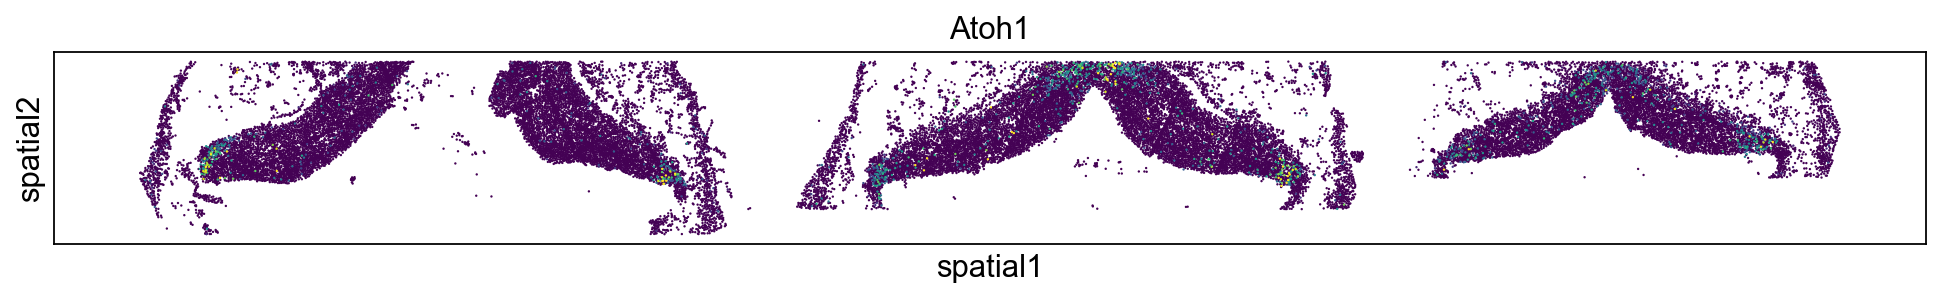

In [9]:
sc.pl.spatial(orig_data, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [10]:
pd.DataFrame(orig_data.obsm["spatial"], columns=["x", "y"]).describe()

,x,y
count,32511.000000,32511.000000
mean,26753.770966,2085.528970
std,15536.571268,1121.738494
min,0.000000,0.000000
25%,13410.455624,1191.122112
50%,27908.325570,2143.839392
75%,38385.971116,2912.906245
max,54134.627302,5497.083974


In [11]:
scaled_data = scale_spatial(orig_data)

In [18]:
pd.DataFrame(scaled_data.obsm["spatial"], columns=["x", "y"]).describe()

,x,y
count,32511.000000,32511.000000
mean,4942.080938,385.248606
std,2869.987666,207.212749
min,0.000000,0.000000
25%,2477.241701,220.029614
50%,5155.355631,396.019978
75%,7090.835022,538.085582
max,10000.000000,1015.446905


In [36]:
# Calculate the 50th percentile (median) for x and y
spatial_median = np.percentile(scaled_data.obsm["spatial"], 50, axis=0)

# Store the values in the spatial_target dictionary
spatial_target["e13_x"] = np.round(spatial_median[0])
spatial_target["e13_y"] = np.round(spatial_median[1])

# Verify the updated dictionary
print(spatial_target)

{'p0_x': 5558.0, 'p0_y': 236.0, 'p4_x': 4511.0, 'p4_y': 233.0}


In [37]:
# Compute top 10 DEGs by 'louvain' clusters and save as subdata
degs = subset_top10_deg(scaled_data, n_top_genes=10)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:01:21)


In [38]:
degs

AnnData object with n_obs × n_vars = 159933 × 95
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'cell_types', 'excitatory', 'inhibitory'
    uns: 'rank_genes_groups', 'top10_deg_genes'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_cell_types']`


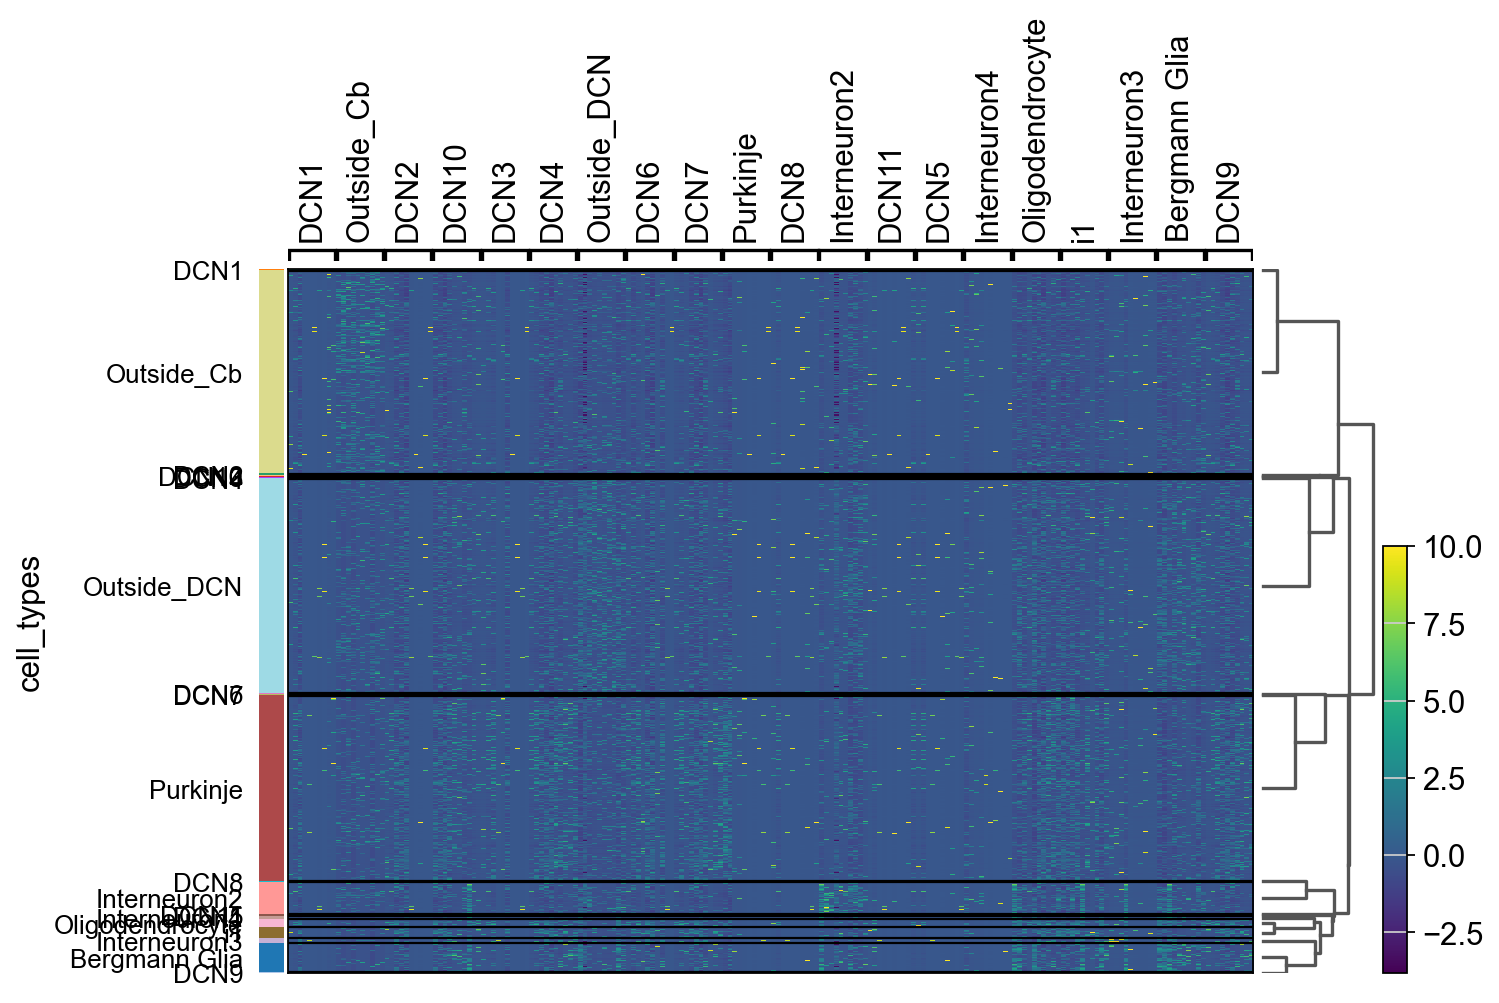

In [39]:
sc.pl.rank_genes_groups_heatmap(degs, key="rank_genes_groups", groupby="cell_types", show=True)

In [40]:
output_dir = '/Users/iriskwon/Library/CloudStorage/OneDrive-SharedLibraries-JohnsHopkins/Manjari Anant - Iris/website_data_09_2025/processed_zarr'

#scaled_data.write_zarr(f"{output_dir}/e13_full.zarr")
degs.write_zarr(f"{output_dir}/p4_top10_degs.zarr")

In [41]:
spatial_target

{'p0_x': 5558.0, 'p0_y': 236.0, 'p4_x': 4511.0, 'p4_y': 233.0}

In [42]:
scaled_data.obs_keys

<bound method AnnData.obs_keys of AnnData object with n_obs × n_vars = 159933 × 1740
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'cell_types', 'excitatory', 'inhibitory'
    uns: 'rank_genes_groups'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'>

In [14]:
orig_data

AnnData object with n_obs × n_vars = 32511 × 1742
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'broad_cell_types', 'cell_types', 'excitatory', 'inhibitory'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial'

### Manual check with Vitessce Config 

In [19]:
from vitessce import VitessceConfig, ViewType as vt, CoordinationType as ct, AnnDataWrapper
output_dir = '/Users/iriskwon/Library/CloudStorage/OneDrive-SharedLibraries-JohnsHopkins/Manjari Anant - Iris/website_data_09_2025/processed_zarr'

# Set up the config
vc = VitessceConfig(schema_version="1.0.15", name="E13 Coronal")

# Define Zarr path
zarr_path = f"{output_dir}/e13_top10_degs.zarr"

# Create wrapper for spatial and expression data
w = AnnDataWrapper(
    adata_path=zarr_path,
    obs_feature_matrix_path="X",  # Point to the top 10 DEGs matrix
    obs_locations_path="obsm/spatial",
    obs_set_paths=["obs/cell_types", "obs/excitatory", "obs/inhibitory", "obs/library_id"],
    obs_set_names=["Cell Types", "Excitatory", "Inhibitory", "Slice (Anterior to Posterior)"]
)

dataset = vc.add_dataset(name="E13").add_object(w)


# === Add views ===
desc = vc.add_view(vt.DESCRIPTION, dataset=dataset).set_props(description="Developing Mouse Cerebellum Coronal Slice")
spatial = vc.add_view(vt.SPATIAL, dataset=dataset)
genes = vc.add_view(vt.FEATURE_LIST, dataset=dataset)
cell_sets = vc.add_view(vt.OBS_SETS, dataset=dataset)
heatmap = vc.add_view(vt.HEATMAP, dataset=dataset)

# Add spatial layer styling and spatial coordination AFTER spatial is defined
spatial_segmentation_layer_value = {
    "shape": "circle",  # Check if this is the correct shape
    "opacity": 1,
    "radius": 9,
    "visible": True,
    "stroked": False
}

vc.link_views(
    [spatial],
    [ct.SPATIAL_ZOOM, ct.SPATIAL_TARGET_X, ct.SPATIAL_TARGET_Y, ct.SPATIAL_SEGMENTATION_LAYER],
    [-3.2, 4942.0, 385.0, spatial_segmentation_layer_value]
)

vc.link_views(
    [heatmap],
    [ct.HEATMAP_ZOOM_X, ct.HEATMAP_ZOOM_Y],
    [1.5, 1]
)

# Layout (genes, scatter)
vc.layout((desc / spatial) / (cell_sets | genes | heatmap))


# Render the widget
vw = vc.widget()
vw

VitessceWidget(config={'version': '1.0.15', 'name': 'E13 Coronal', 'description': '', 'datasets': [{'uid': 'A'…

In [20]:
# Export your config to a Python dictionary
config_dict = vc.to_dict(base_url="configs_for_vitessce")

import json 

# Write it to a JS file for your React app
with open("configs_for_vitessce/e13-config.js", "w") as f:
    f.write("export const e13Config = ")
    json.dump(config_dict, f, indent=2)
    f.write(";")


## E13

In [69]:
e13_data_orig = ad.read_h5ad("data_for_vitessce/e13_data.h5ad")

In [ ]:
e13_data_orig

In [ ]:
sc.pl.spatial(e13_data_orig, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [ ]:
pd.DataFrame(e13_data_orig.obsm["spatial"], columns=["x", "y"]).describe()

In [42]:
e13_data_scaled = scale_spatial(e13_data_orig)

In [ ]:
pd.DataFrame(e13_data_scaled.obsm["spatial"], columns=["x", "y"]).describe()

In [ ]:
# Calculate the 50th percentile (median) for x and y
spatial_median = np.percentile(e13_data_scaled.obsm["spatial"], 50, axis=0)

# Store the values in the spatial_target dictionary
spatial_target["e13_x"] = np.round(spatial_median[0])
spatial_target["e13_y"] = np.round(spatial_median[1])

# Verify the updated dictionary
print(spatial_target)

In [ ]:
# Compute top 10 DEGs by 'louvain' clusters and save as subdata
e13_degs = subset_top10_deg(e13_data_scaled, n_top_genes=10)

In [ ]:
e13_degs

In [ ]:
e13_degs.write_zarr("res_for_vitessce/e13_top10_deg.zarr")
print(f"Saved top 10 DEG subset to Zarr with {(e13_degs.shape)[1]} genes.")

In [46]:
e13_data_scaled.write_zarr("mouse-cereb-dev/public/data/e13_full.zarr")

In [ ]:
spatial_target

In [ ]:
from vitessce import VitessceConfig, ViewType as vt, CoordinationType as ct, AnnDataWrapper

# Set up the config
vc = VitessceConfig(schema_version="1.0.15", name="E11 Coronal")

# Define Zarr path
zarr_path = "res_for_vitessce/e13_top10_deg.zarr"

# Create wrapper for spatial and expression data
w = AnnDataWrapper(
    adata_path=zarr_path,
    obs_feature_matrix_path="X",  # Point to the top 10 DEGs matrix
    obs_locations_path="obsm/spatial",
    obs_set_paths=["obs/cell_types", "obs/broad_cell_types", "obs/library_id"],
    obs_set_names=["Cell Type", "Broad Cell Types", "Coronal Slice (Anterior to Posterior"]
)

dataset = vc.add_dataset(name="E13").add_object(w)


# === Add views ===
desc = vc.add_view(vt.DESCRIPTION, dataset=dataset).set_props(description="Developing Mouse Cerebellum (E13) Coronal Slice")
spatial = vc.add_view(vt.SPATIAL, dataset=dataset)
genes = vc.add_view(vt.FEATURE_LIST, dataset=dataset)
cell_sets = vc.add_view(vt.OBS_SETS, dataset=dataset)
heatmap = vc.add_view(vt.HEATMAP, dataset=dataset)

# Add spatial layer styling and spatial coordination AFTER spatial is defined
spatial_segmentation_layer_value = {
    "shape": "circle",  # Check if this is the correct shape
    "opacity": 1,
    "radius": 9,
    "visible": True,
    "stroked": False
}

vc.link_views(
    [spatial],
    [ct.SPATIAL_ZOOM, ct.SPATIAL_TARGET_X, ct.SPATIAL_TARGET_Y, ct.SPATIAL_SEGMENTATION_LAYER],
    [-3, 5000, 688, spatial_segmentation_layer_value]
)

vc.link_views(
    [heatmap],
    [ct.HEATMAP_ZOOM_X, ct.HEATMAP_ZOOM_Y],
    [2, 5]
)

# Layout (genes, scatter)
#vc.layout(desc / (spatial) / (cell_sets | genes | heatmap))
vc.layout(desc / (spatial) / (cell_sets | genes | heatmap))


# Render the widget
vw = vc.widget()
vw

In [33]:
# Export your config to a Python dictionary
config_dict = vc.to_dict(base_url="configs_for_vitessce")


import json 

# Write it to a JS file for your React app
with open("configs_for_vitessce/e13-config.js", "w") as f:
    f.write("export const e13Config = ")
    json.dump(config_dict, f, indent=2)
    f.write(";")


## E15 and E17

In [79]:
e15_data_orig = ad.read_h5ad("data_for_vitessce/e15_data.h5ad")
e17_data_orig = ad.read_h5ad("data_for_vitessce/e17_data.h5ad")

In [ ]:
e15_data_orig

In [ ]:
e17_data_orig

In [ ]:
sc.pl.spatial(e15_data_orig, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [ ]:
sc.pl.spatial(e17_data_orig, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [ ]:
e15_data_scaled = scale_spatial(e15_data_orig)
e17_data_scaled = scale_spatial(e17_data_orig)

pd.DataFrame(e15_data_scaled.obsm["spatial"], columns=["x", "y"]).describe()

In [53]:
e15_data_scaled.write_zarr("mouse-cereb-dev/public/data/e15_full.zarr")
e17_data_scaled.write_zarr("mouse-cereb-dev/public/data/e17_full.zarr")

In [ ]:
pd.DataFrame(e17_data_scaled.obsm["spatial"], columns=["x", "y"]).describe()

In [ ]:
# Calculate the 50th percentile (median) for x and y
spatial_median = np.percentile(e15_data_scaled.obsm["spatial"], 50, axis=0)

# Store the values in the spatial_target dictionary
spatial_target["e15_x"] = np.round(spatial_median[0])
spatial_target["e15_y"] = np.round(spatial_median[1])

# Verify the updated dictionary
print(spatial_target)

In [ ]:
# Calculate the 50th percentile (median) for x and y
spatial_median = np.percentile(e17_data_scaled.obsm["spatial"], 50, axis=0)

# Store the values in the spatial_target dictionary
spatial_target["e17_x"] = np.round(spatial_median[0])
spatial_target["e17_y"] = np.round(spatial_median[1])

# Verify the updated dictionary
print(spatial_target)

In [ ]:
e15_degs = subset_top10_deg(e15_data_scaled, n_top_genes=10)

In [ ]:
# Compute top 10 DEGs by 'louvain' clusters and save as subdata
e17_degs = subset_top10_deg(e17_data_scaled, n_top_genes=10)

In [ ]:
e15_degs 

In [ ]:
e17_degs

In [ ]:
e15_degs.write_zarr("res_for_vitessce/e15_top10_deg.zarr")
print(f"Saved top 10 DEG subset to Zarr with {(e15_degs.shape)[1]} genes.")

In [ ]:
e17_degs.write_zarr("res_for_vitessce/e17_top10_deg.zarr")
print(f"Saved top 10 DEG subset to Zarr with {(e17_degs.shape)[1]} genes.")

In [ ]:
spatial_target

In [ ]:
from vitessce import VitessceConfig, ViewType as vt, CoordinationType as ct, AnnDataWrapper

# Set up the config
vc = VitessceConfig(schema_version="1.0.15", name="E11 Coronal")

# Define Zarr path
zarr_path = "res_for_vitessce/e15_top10_deg.zarr"

# Create wrapper for spatial and expression data
w = AnnDataWrapper(
    adata_path=zarr_path,
    obs_feature_matrix_path="X",  # Point to the top 10 DEGs matrix
    obs_locations_path="obsm/spatial",
    obs_set_paths=["obs/cell_types", "obs/broad_cell_types", "obs/library_id"],
    obs_set_names=["Cell Type", "Broad Cell Types", "Coronal Slice (Anterior to Posterior"]
)

dataset = vc.add_dataset(name="E15").add_object(w)


# === Add views ===
#desc = vc.add_view(vt.DESCRIPTION, dataset=dataset).set_props(description="Developing Mouse Cerebellum (E13) Coronal Slice")
spatial = vc.add_view(vt.SPATIAL, dataset=dataset)
genes = vc.add_view(vt.FEATURE_LIST, dataset=dataset)
cell_sets = vc.add_view(vt.OBS_SETS, dataset=dataset)
heatmap = vc.add_view(vt.HEATMAP, dataset=dataset)

# Add spatial layer styling and spatial coordination AFTER spatial is defined
spatial_segmentation_layer_value = {
    "shape": "circle",  # Check if this is the correct shape
    "opacity": 1,
    "radius": 10,
    "visible": True,
    "stroked": False
}

vc.link_views(
    [spatial],
    [ct.SPATIAL_ZOOM, ct.SPATIAL_TARGET_X, ct.SPATIAL_TARGET_Y, ct.SPATIAL_SEGMENTATION_LAYER],
    [-3, 5190, 468, spatial_segmentation_layer_value]
)

vc.link_views(
    [heatmap],
    [ct.HEATMAP_ZOOM_X, ct.HEATMAP_ZOOM_Y],
    [2, 5]
)

# Layout (genes, scatter)
#vc.layout(desc / (spatial) / (cell_sets | genes | heatmap))
vc.layout((spatial) / (cell_sets | genes | heatmap))


# Render the widget
vw = vc.widget()
vw

In [40]:
# Export your config to a Python dictionary
config_dict = vc.to_dict(base_url="configs_for_vitessce")


import json 

# Write it to a JS file for your React app
with open("configs_for_vitessce/e15-config.js", "w") as f:
    f.write("export const e15Config = ")
    json.dump(config_dict, f, indent=2)
    f.write(";")


In [ ]:
from vitessce import VitessceConfig, ViewType as vt, CoordinationType as ct, AnnDataWrapper

# Set up the config
vc = VitessceConfig(schema_version="1.0.15", name="E17 Coronal")

# Define Zarr path
zarr_path = "res_for_vitessce/e17_top10_deg.zarr"

# Create wrapper for spatial and expression data
w = AnnDataWrapper(
    adata_path=zarr_path,
    obs_feature_matrix_path="X",  # Point to the top 10 DEGs matrix
    obs_locations_path="obsm/spatial",
    obs_set_paths=["obs/cell_types", "obs/broad_cell_types", "obs/library_id"],
    obs_set_names=["Cell Type", "Broad Cell Types", "Coronal Slice (Anterior to Posterior"]
)

dataset = vc.add_dataset(name="E17").add_object(w)


# === Add views ===
desc = vc.add_view(vt.DESCRIPTION, dataset=dataset).set_props(description="Developing Mouse Cerebellum (E13) Coronal Slice")
spatial = vc.add_view(vt.SPATIAL, dataset=dataset)
genes = vc.add_view(vt.FEATURE_LIST, dataset=dataset)
cell_sets = vc.add_view(vt.OBS_SETS, dataset=dataset)
heatmap = vc.add_view(vt.HEATMAP, dataset=dataset)

# Add spatial layer styling and spatial coordination AFTER spatial is defined
spatial_segmentation_layer_value = {
    "shape": "circle",  # Check if this is the correct shape
    "opacity": 1,
    "radius": 10,
    "visible": True,
    "stroked": False
}

vc.link_views(
    [spatial],
    [ct.SPATIAL_ZOOM, ct.SPATIAL_TARGET_X, ct.SPATIAL_TARGET_Y, ct.SPATIAL_SEGMENTATION_LAYER],
    [-4.5, 3893, 2383, spatial_segmentation_layer_value]
)

vc.link_views(
    [heatmap],
    [ct.HEATMAP_ZOOM_X, ct.HEATMAP_ZOOM_Y],
    [2, 5]
)

# Layout (genes, scatter)
#vc.layout(desc / (spatial) / (cell_sets | genes | heatmap))
vc.layout((desc | spatial) / (cell_sets | genes | heatmap))


# Render the widget
vw = vc.widget()
vw

In [ ]:
os.getcwd()

In [102]:
# Export your config to a Python dictionary
config_dict = vc.to_dict(base_url="configs_for_vitessce")


import json 

# Write it to a JS file for your React app
with open("configs_for_vitessce/e17-config.js", "w") as f:
    f.write("export const e17Config = ")
    json.dump(config_dict, f, indent=2)
    f.write(";")
